In [118]:
#THIS AIMS TO IMPROVE 01_Baseline_NN.ipynb by adding rolling features

In [119]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import tensorflow as tf

# For reproducibility
np.random.seed(1717)
tf.random.set_seed(1717)

In [120]:
# 1. Load the dataset (races from 2022-2025)
df = pd.read_csv('../../data/raw/f1_strategy_dataset_v6.csv')

In [121]:
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change,Prev_TyreLife
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0.0,0.017241,0.117647,0.0,NaN
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0.0,0.034483,0.176471,-1.0,2.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0.0,0.051724,0.235294,0.0,3.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0.0,0.068966,0.294118,0.0,4.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0.0,0.086207,0.352941,0.0,5.0


In [122]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  str    
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  str    
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  str    
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101370 non-null  float64
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife     101371 

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change,Prev_TyreLife
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101370.000000,101371.000000,101371.000000,101371.000000,99523.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.028815,0.028815,0.432618,0.386521,-0.004636,14.355134
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.167287,0.167288,0.258129,0.259906,3.912725,10.177389
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000,1.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000,6.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000,12.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,0.000000,0.000000,0.631579,0.562500,2.000000,20.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000,77.000000


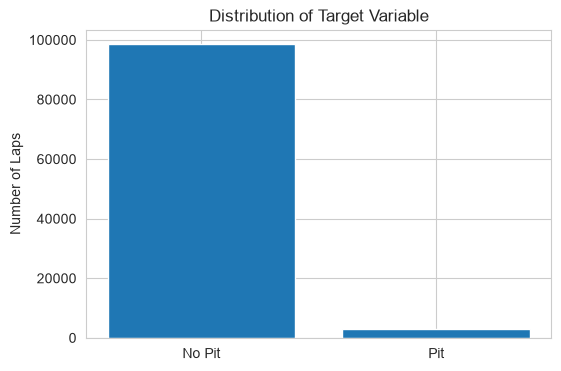

In [123]:
import matplotlib.pyplot as plt

pit_counts = df["PitNextLap"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(["No Pit","Pit"], pit_counts)

plt.title("Distribution of Target Variable")

plt.ylabel("Number of Laps")

plt.show()

# In your dissertation you could discuss:
#
# The dataset is expected to be highly imbalanced because pit stops occur infrequently relative to the total number of racing laps.
#
# This naturally motivates later use of class weights.

In [124]:
#Pit stop percentage
pit_percentage = df["PitNextLap"].mean()*100

print(f"Pit stops next lap: {pit_percentage:.2f}%")

Pit stops next lap: 2.88%


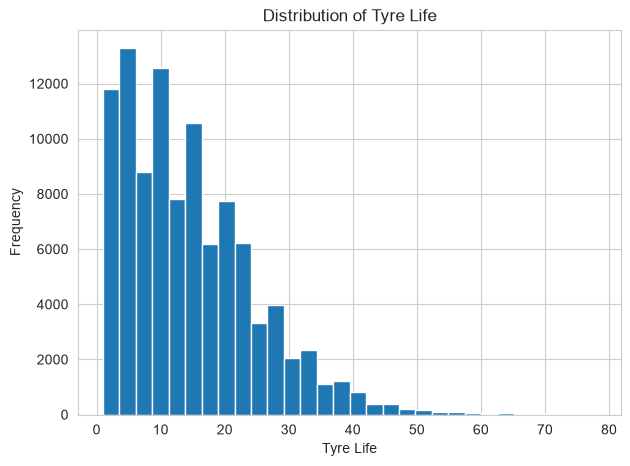

In [125]:
#Distribution of TyreLife

plt.figure(figsize=(7,5))

plt.hist(df["TyreLife"], bins=30)

plt.xlabel("Tyre Life")

plt.ylabel("Frequency")

plt.title("Distribution of Tyre Life")

plt.show()

# Questions to answer:
#
# Is it skewed?
# Does it have multiple peaks?
# Are there impossible values?

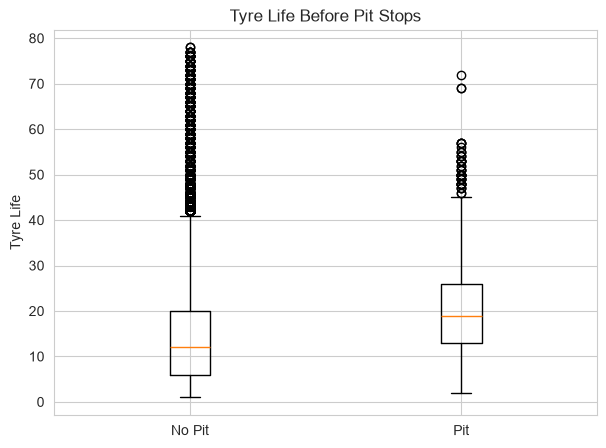

In [126]:
#TyreLife by PitNextLap

#One of the most informative plots.

plt.figure(figsize=(7,5))

plt.boxplot(
    [
        df[df["PitNextLap"]==0]["TyreLife"],
        df[df["PitNextLap"]==1]["TyreLife"]
    ],
    tick_labels=["No Pit","Pit"]
)

plt.ylabel("Tyre Life")

plt.title("Tyre Life Before Pit Stops")

plt.show()

# Expected result:
#
# Drivers who pit next lap should generally have older tyres.
#
# This provides evidence that TyreLife is an important predictor.

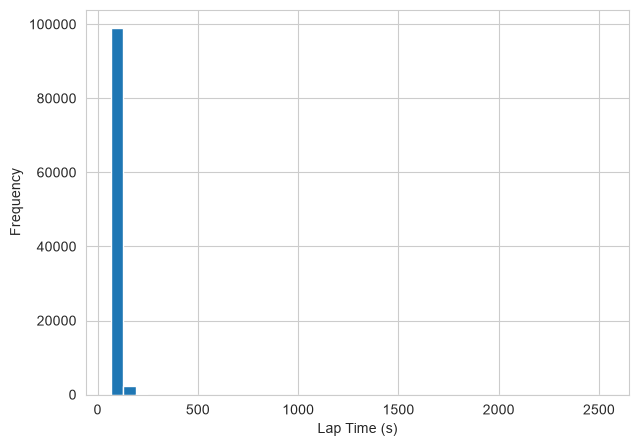

In [127]:
#Lap Time distribution

plt.figure(figsize=(7,5))

plt.hist(df["LapTime (s)"], bins=40)

plt.xlabel("Lap Time (s)")

plt.ylabel("Frequency")

plt.show()

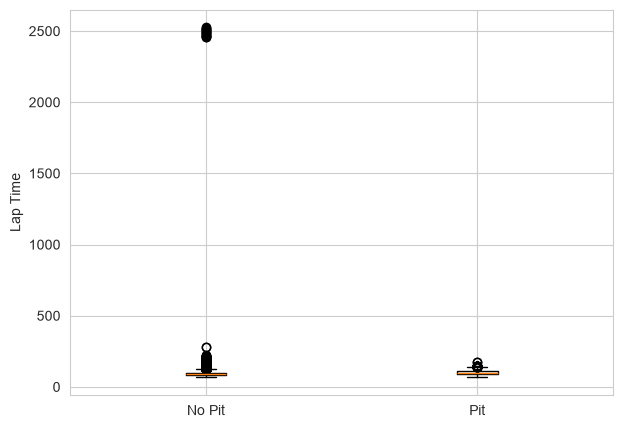

In [128]:
#Lap Time by Pit Decision
plt.figure(figsize=(7,5))

plt.boxplot(
[
df[df["PitNextLap"]==0]["LapTime (s)"],
df[df["PitNextLap"]==1]["LapTime (s)"]
],
tick_labels=["No Pit","Pit"]
)

plt.ylabel("Lap Time")

plt.show()

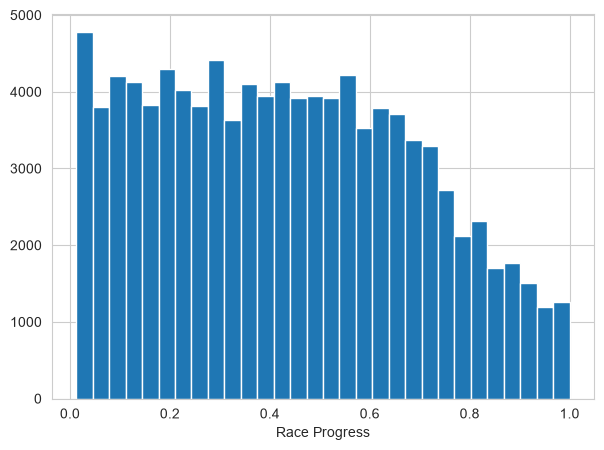

In [129]:
#Race Progress
plt.figure(figsize=(7,5))

plt.hist(df["RaceProgress"], bins=30)

plt.xlabel("Race Progress")

plt.show()

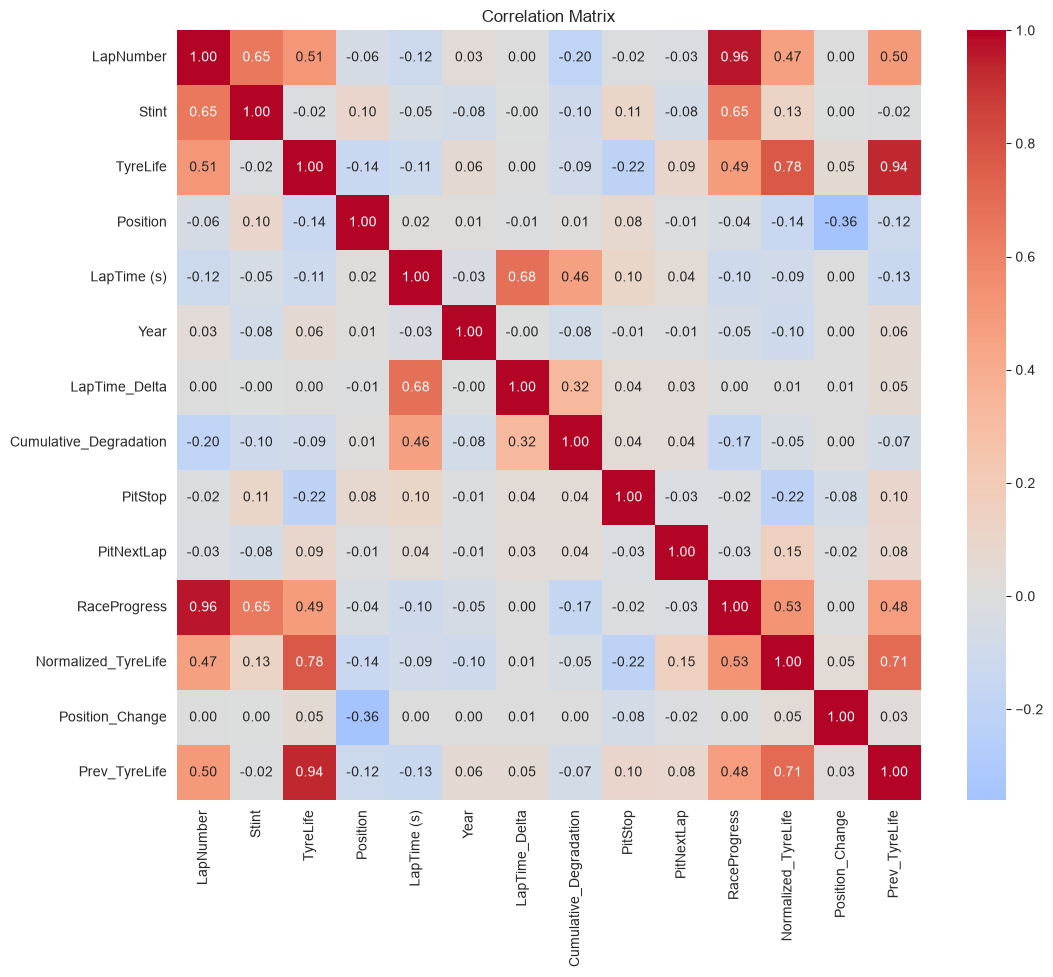

In [130]:
#Correlation Heatmap

import seaborn as sns

numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,10))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

#This is where you can discuss why Normalized_TyreLife is removed.

In [131]:
#Remove unnecessary columns
df = df.drop(columns=[
    "Normalized_TyreLife",
    "PitStop"
])

In [132]:
#check for any missing data
df.isnull().sum()

Driver                       0
LapNumber                    0
Compound                    66
Stint                        0
TyreLife                     0
Position                     0
LapTime (s)                  0
Race                         0
Year                         0
LapTime_Delta                0
Cumulative_Degradation       0
PitNextLap                   1
RaceProgress                 0
Position_Change              0
Prev_TyreLife             1848
dtype: int64

In [133]:
#drop rows with missing tire compound
df = df.dropna(subset=['Compound'])

In [134]:
#examine the row with missing PitNextLap --> this is the last lap of the USGP so we will manually set that value to 0.0
df[df['PitNextLap'].isnull()]

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitNextLap,RaceProgress,Position_Change,Prev_TyreLife
101370,ZHO,56,HARD,3,33.0,14,103.881,United States Grand Prix,2022,21.39,-89.756,NaN,0.777778,4.0,32.0


In [135]:
#manually filling in the data for this and also fixing issue with missing sata for PitNextLap
df.loc[df.index[-1], 'PitNextLap'] = 0.0
df["Prev_TyreLife"] = df["Prev_TyreLife"].fillna(0)

In [136]:
#Now we should be OK
df.isnull().sum()

Driver                    0
LapNumber                 0
Compound                  0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
Race                      0
Year                      0
LapTime_Delta             0
Cumulative_Degradation    0
PitNextLap                0
RaceProgress              0
Position_Change           0
Prev_TyreLife             0
dtype: int64

In [137]:
#add some deeper features!

#Tyre wear relative to race progress
df["TyreWearRate"] = df["TyreLife"] / (df["RaceProgress"] + 0.01)

# Remaining race
df["RemainingRace"] = 1 - df["RaceProgress"]

# Squared tyre age
df["TyreLifeSquared"] = df["TyreLife"] ** 2

In [138]:
# Sort chronologically within each driver and race

df = df.sort_values(
    by=["Year", "Race", "Driver", "LapNumber"]
)

In [139]:
#Create ROLLING FEATURES!!

# Rolling average of lap time over previous 3 laps
df["RollingLapTime3"] = (
    df.groupby(["Year", "Race", "Driver"])["LapTime (s)"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling average over previous 5 laps
df["RollingLapTime5"] = (
    df.groupby(["Year", "Race", "Driver"])["LapTime (s)"]
      .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

#Rolling degradation
df["RollingDelta3"] = (
    df.groupby(["Year","Race","Driver"])["LapTime_Delta"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

df["RollingDelta5"] = (
    df.groupby(["Year","Race","Driver"])["LapTime_Delta"]
      .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

In [140]:
#Extra feature additions related to lap times!

df["PreviousLapTime"] = (
    df.groupby(["Year","Race","Driver"])["LapTime (s)"]
      .shift(1)
)

df["PreviousLapTime"] = df["PreviousLapTime"].fillna(df["LapTime (s)"])

#Lap Time Increase
df["LapTimeIncrease"] = (
    df["LapTime (s)"] -
    df["PreviousLapTime"]
)

In [141]:
#Split data into training, validation, and testing data using a CHRONOLOGICAL SPLIT

#To prevent temporal leakage and better simulate real-world deployment, we will train the neural network using data from the 2022–2024 Formula One seasons and evaluate it on the unseen 2025 season!

train_df = df[df["Year"].isin([2022, 2023])]

val_df = df[df["Year"] == 2024]

test_df = df[df["Year"] == 2025]

In [142]:
#Verify split sizes

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(46708, 24)
(27557, 24)
(27040, 24)


In [143]:
#Establish inputs and outputs of the neural network

X_train = train_df.drop("PitNextLap", axis=1)
y_train = train_df["PitNextLap"]

X_val = val_df.drop("PitNextLap", axis=1)
y_val = val_df["PitNextLap"]

X_test = test_df.drop("PitNextLap", axis=1)
y_test = test_df["PitNextLap"]

In [144]:
#Identify feature types

categorical_features = [
    "Driver",
    "Compound",
    "Race"
]

numerical_features = [

    "LapNumber",
    "Stint",
    "TyreLife",
    "TyreLifeSquared",
    "TyreWearRate",
    "RemainingRace",

    "Position",

    "LapTime (s)",
    "LapTime_Delta",
    "PreviousLapTime",
    "LapTimeIncrease",

    "RollingLapTime3",
    "RollingLapTime5",

    "RollingDelta3",
    "RollingDelta5",

    "Cumulative_Degradation",
    "RaceProgress",
    "Position_Change",
    "Prev_TyreLife"

]

In [145]:
#Build preprocessing pipeline! (one-hot encoding and standard scaling)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#preventing errors from changes to F1 driver lineups
handle_unknown="ignore"

In [146]:
#Fitting on training data

X_train = preprocessor.fit_transform(X_train)

X_val = preprocessor.transform(X_val)

X_test = preprocessor.transform(X_test)

In [147]:
#Checking resulting dimensions

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(46708, 76)
(27557, 76)
(27040, 76)


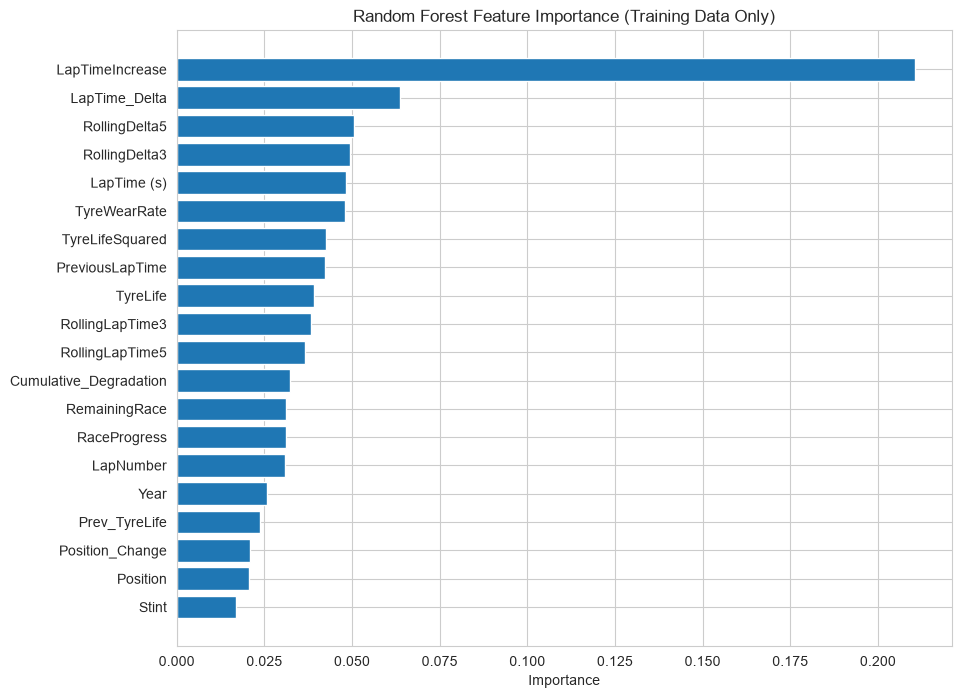

In [148]:
#Evaluating FEATURE IMPORTANCE!

from sklearn.ensemble import RandomForestClassifier

# Training features only
rf_X_train = train_df.drop(columns=["PitNextLap"])

# Training target only
rf_y_train = train_df["PitNextLap"]

#one-hot encode categorical variables
rf_X_train = pd.get_dummies(
    rf_X_train,
    drop_first=True
)

#Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=1717,
    n_jobs=-1
)

rf.fit(rf_X_train, rf_y_train)

#Get feature importances
importance = pd.DataFrame({

    "Feature": rf_X_train.columns,

    "Importance": rf.feature_importances_

})

#Sort
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

#Plot
plt.figure(figsize=(10,8))

top20 = importance.head(20)

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance (Training Data Only)")

plt.show()

In [149]:
#Convert target vars to NumPy arrays (more friendly for TensorFlow)

y_train = y_train.values

y_val = y_val.values

y_test = y_test.values

In [150]:
#Check class balances

print(pd.Series(y_train).value_counts())

print(pd.Series(y_train).value_counts(normalize=True))

0.0    45250
1.0     1458
Name: count, dtype: int64
0.0    0.968785
1.0    0.031215
Name: proportion, dtype: float64


In [151]:
#Importing Libraries for the neural network

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.layers import BatchNormalization

In [152]:
#for an adaptive learning rate

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1
)

In [153]:
#Building neural network! yeyyyy

model = Sequential([

    Dense(128, input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.30),

    Dense(64),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.30),

    Dense(32),
    BatchNormalization(),
    tf.keras.layers.ReLU(),

    Dense(1, activation="sigmoid")
])

C:\Users\krish\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [154]:
#Compile!

#set optimizer
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer = optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [155]:
#EarlyStopping (stops training automatically when the model stops improving)

early_stop = EarlyStopping(

monitor="val_loss",

patience=8,

restore_best_weights=True

)

In [156]:
#Handle Class Balance

from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.float64(0.0): np.float64(0.5161104972375691), np.float64(1.0): np.float64(16.017832647462278)}


In [157]:
#Train the model

history = model.fit(

X_train,

y_train,

validation_data=(X_val,y_val),

epochs=100,

batch_size=64,

callbacks=[early_stop, reduce_lr],

class_weight=class_weights

)

Epoch 1/100
730/730 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7444 - loss: 0.4713 - val_accuracy: 0.8053 - val_loss: 0.4323 - learning_rate: 0.0010
Epoch 2/100
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8395 - loss: 0.3443 - val_accuracy: 0.8495 - val_loss: 0.3448 - learning_rate: 0.0010
Epoch 3/100
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8621 - loss: 0.2927 - val_accuracy: 0.8665 - val_loss: 0.2875 - learning_rate: 0.0010
Epoch 4/100
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8792 - loss: 0.2608 - val_accuracy: 0.9045 - val_loss: 0.2251 - learning_rate: 0.0010
Epoch 5/100
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8905 - loss: 0.2392 - val_accuracy: 0.9212 - val_loss: 0.1975 - learning_rate: 0.0010
Epoch 6/100
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8991 - loss: 0.2180 - val_accuracy: 0.9324 - val_loss: 0.1692 - learning_rate: 0.0010
Epoch 7/100
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9082 - loss: 0.

In [158]:
# Predict probabilities on the validation set (2024)

y_val_prob = model.predict(X_val).flatten()

862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


In [159]:
#Testing the accuracy metrics of the validation (precision, recall, f1-score) with different thresholds!

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.9991, 0.005)

results = []

best_threshold = 0.50
best_f1 = 0

for threshold in thresholds:

    predictions = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, predictions, zero_division=0)
    recall = recall_score(y_val, predictions, zero_division=0)
    f1 = f1_score(y_val, predictions, zero_division=0)

    results.append([threshold, precision, recall, f1])

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best Threshold = {best_threshold:.2f}")
print(f"Best Validation F1 = {best_f1:.3f}")

Best Threshold = 0.94
Best Validation F1 = 0.695


In [160]:
results = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1"]
)

results.sort_values(
    by="F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
168,0.940,0.667888,0.725464,0.695486
171,0.955,0.718750,0.671088,0.694102
170,0.950,0.697051,0.689655,0.693333
169,0.945,0.681178,0.705570,0.693160
167,0.935,0.650235,0.734748,0.689913
172,0.960,0.743827,0.639257,0.687589
166,0.930,0.638128,0.741379,0.685890
165,0.925,0.625828,0.751989,0.683133
164,0.920,0.617457,0.759947,0.681332
173,0.965,0.770134,0.608753,0.680000


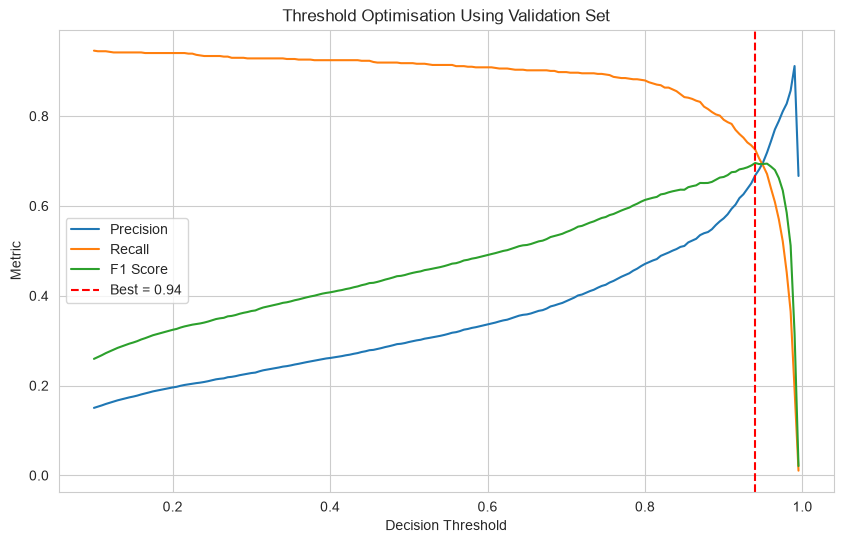

In [161]:
plt.figure(figsize=(10,6))

plt.plot(results["Threshold"], results["Precision"], label="Precision")

plt.plot(results["Threshold"], results["Recall"], label="Recall")

plt.plot(results["Threshold"], results["F1"], label="F1 Score")

plt.axvline(best_threshold,
            color="red",
            linestyle="--",
            label=f"Best = {best_threshold:.2f}")

plt.xlabel("Decision Threshold")

plt.ylabel("Metric")

plt.title("Threshold Optimisation Using Validation Set")

plt.legend()

plt.grid(True)

plt.show()

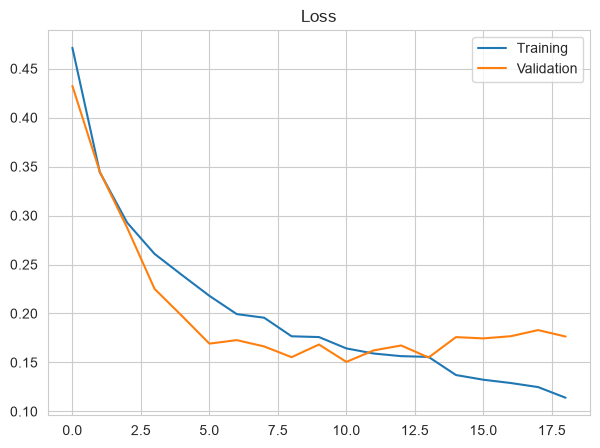

In [162]:
#Loss Curve

plt.figure(figsize=(7,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Training","Validation"])

plt.title("Loss")

plt.show()

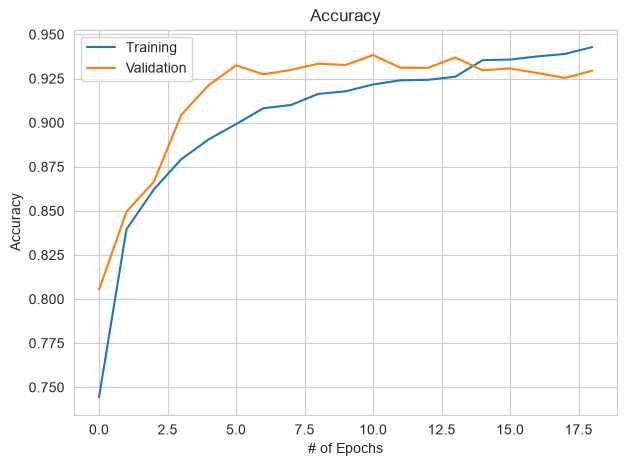

In [163]:
#Accuracy Curve

plt.figure(figsize=(7,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Training","Validation"])

plt.title("Accuracy")

plt.xlabel("# of Epochs")
plt.ylabel("Accuracy")

plt.show()

In [164]:
# Predict probabilities on the unseen 2025 season

y_test_prob = model.predict(X_test).flatten()

y_test_pred = (y_test_prob >= best_threshold).astype(int)

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 861us/step


Text(51.68782552083333, 0.5, 'Actual')

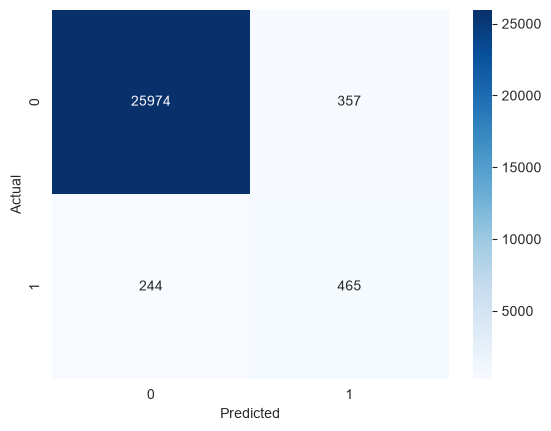

In [165]:
#Confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

In [166]:
#Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     26331
         1.0       0.57      0.66      0.61       709

    accuracy                           0.98     27040
   macro avg       0.78      0.82      0.80     27040
weighted avg       0.98      0.98      0.98     27040



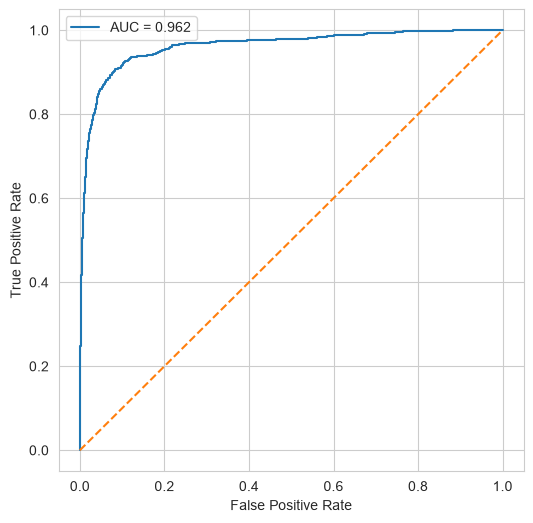

In [167]:
#ROC Curve

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
fpr,tpr,_ = roc_curve(y_test,y_test_prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

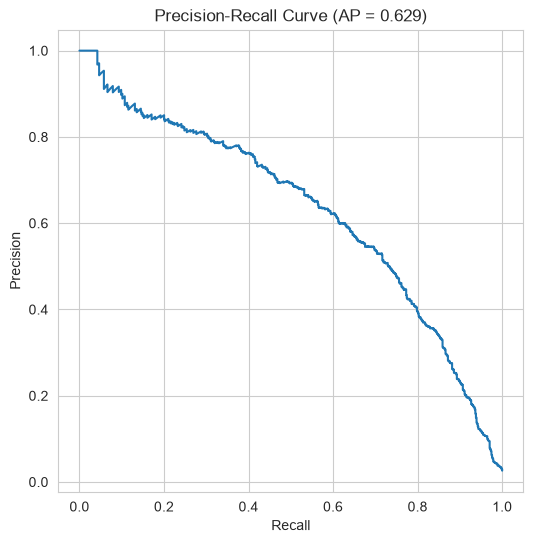

In [168]:
#Precision-Recall Curve

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

ap = average_precision_score(y_test, y_test_prob)

plt.figure(figsize=(6,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(f"Precision-Recall Curve (AP = {ap:.3f})")

plt.show()